# Bài Thực Hành: So Sánh Sự Tương Đồng Của Ảnh Sử Dụng Wavelet

**Môn học:** Xử lý ảnh số / Thị giác máy tính  
**Sinh viên:** [Tên sinh viên]  
**MSSV:** [MSSV]  

---

## Giới thiệu

Trong bài này, chúng ta sẽ thực hiện so sánh sự tương đồng giữa các ảnh dựa trên biến đổi **Wavelet (DWT - Discrete Wavelet Transform)**.

Ý tưởng chính là: thay vì so sánh từng pixel một (tốn kém và nhạy cảm với nhiễu), chúng ta sẽ trích xuất **đặc trưng** của ảnh thông qua biến đổi Wavelet (thành phần xấp xỉ LL), sau đó tạo một **hash nhị phân** và dùng **khoảng cách Hamming** để đo mức độ tương đồng.

**Dữ liệu đầu vào:**
- `similar1.jpg` và `similar2.jpg`: 2 ảnh có nội dung tương tự nhau.
- `different1.jpg` và `different2.jpg`: 2 ảnh có nội dung khác nhau hoàn toàn.

---
## Bước 1: Import Thư Viện và Cấu Hình

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt
import os

from matplotlib.patches import Patch
from sklearn.metrics import roc_curve, auc

# --- CÀI ĐẶT TOÀN CỤC CHO ĐỘ PHÂN GIẢI CAO ---
# Tăng DPI lên 150 để ảnh hiển thị sắc nét hơn trên màn hình
plt.rcParams['figure.dpi']      = 150
plt.rcParams['savefig.dpi']     = 300       # Khi lưu file: 300 DPI (chuẩn in ấn chất lượng cao)
plt.rcParams['savefig.format']  = 'png'
plt.rcParams['savefig.bbox']    = 'tight'   # Tự động cắt bỏ vùng trắng thừa

# Cấu hình Font chữ rõ ràng hơn
plt.rcParams['font.size']       = 11
plt.rcParams['axes.titlesize']  = 13
plt.rcParams['axes.labelsize']  = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

# Thư mục lưu ảnh xuất ra để đưa vào báo cáo
OUTPUT_DIR = "images/bao_cao_anh"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Import và cài đặt thành công!")
print(f"DPI hiển thị : {plt.rcParams['figure.dpi']}")
print(f"DPI lưu file : {plt.rcParams['savefig.dpi']}")
print(f"Thư mục xuất : {OUTPUT_DIR}/")

Import và cài đặt thành công!
DPI hiển thị : 150.0
DPI lưu file : 300.0
Thư mục xuất : images/bao_cao_anh/


---
## Bước 2: Tiền Xử Lý Ảnh

In [5]:
SIZE = 128

def load_and_preprocess(filepath):
    """Đọc ảnh, chuyển xám và resize về kích thước cố định."""
    img = cv2.imread(filepath)
    if img is None:
        raise FileNotFoundError(f"Không tìm thấy file: {filepath}")
    gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (SIZE, SIZE))
    return resized

def load_color(filepath):
    """Đọc ảnh màu (RGB) để hiển thị minh họa trong báo cáo."""
    img = cv2.imread(filepath)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Đọc ảnh xám (dùng cho các thuật toán xử lý)
similar1   = load_and_preprocess(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\conmeo_original.jpg")
similar2   = load_and_preprocess(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\conmeo_rotated.jpg")
different1 = load_and_preprocess(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\images_original.jpg")
different2 = load_and_preprocess(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\ngoinha_original.jpg")

# Đọc ảnh màu (dùng để trình bày trực quan)
similar1_rgb   = load_color(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\conmeo_original.jpg")
similar2_rgb   = load_color(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\conmeo_rotated.jpg")
different1_rgb = load_color(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\images_original.jpg")
different2_rgb = load_color(r"D:\HocTangCuong\xulianhvathigiacmt\lab4_dataset\ngoinha_original.jpg")

print(f"Đọc ảnh thành công! Kích thước xử lý: {similar1.shape}")

Đọc ảnh thành công! Kích thước xử lý: (128, 128)


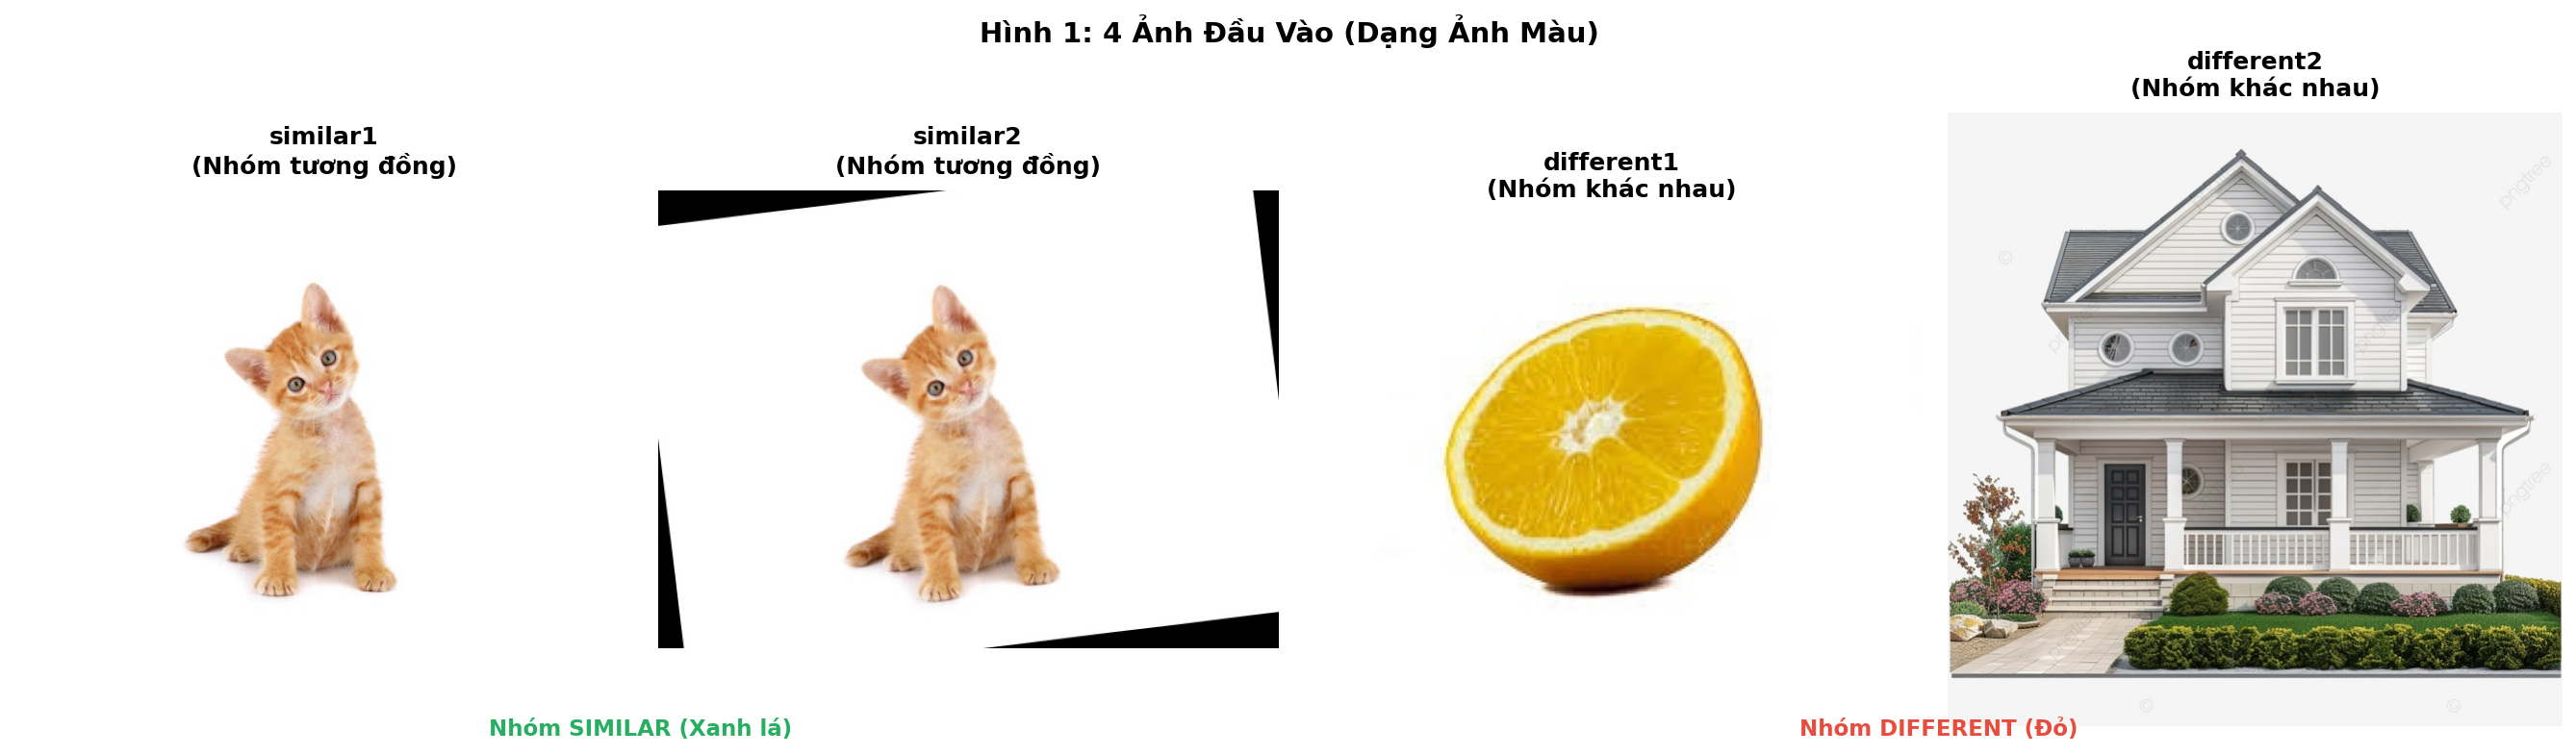

Đã lưu: hinh1_anh_goc.png


In [6]:
# === Hình 1: Hiển thị 4 ảnh gốc màu (Minh họa báo cáo) ===
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

color_imgs = [similar1_rgb, similar2_rgb, different1_rgb, different2_rgb]
titles     = ["similar1", "similar2", "different1", "different2"]
subtitles  = ["(Nhóm tương đồng)", "(Nhóm tương đồng)",
              "(Nhóm khác nhau)",  "(Nhóm khác nhau)"]
border_colors = ["#27ae60", "#27ae60", "#e74c3c", "#e74c3c"]

for ax, img, title, sub, bc in zip(axes, color_imgs, titles, subtitles, border_colors):
    ax.imshow(img)
    ax.set_title(f"{title}\n{sub}", fontsize=12, fontweight='bold', pad=8)
    ax.axis("off")
    # Thêm khung màu để phân biệt nhóm ảnh trực quan
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(bc)
        spine.set_linewidth(3)

# Thêm chú thích cho các nhóm ảnh
fig.text(0.25, 0.02, "Nhóm SIMILAR (Xanh lá)",
         ha='center', fontsize=11, color='#27ae60', fontweight='bold')
fig.text(0.75, 0.02, "Nhóm DIFFERENT (Đỏ)",
         ha='center', fontsize=11, color='#e74c3c', fontweight='bold')

plt.suptitle("Hình 1: 4 Ảnh Đầu Vào (Dạng Ảnh Màu)",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh1_anh_goc.png")
plt.show()
print("Đã lưu: hinh1_anh_goc.png")

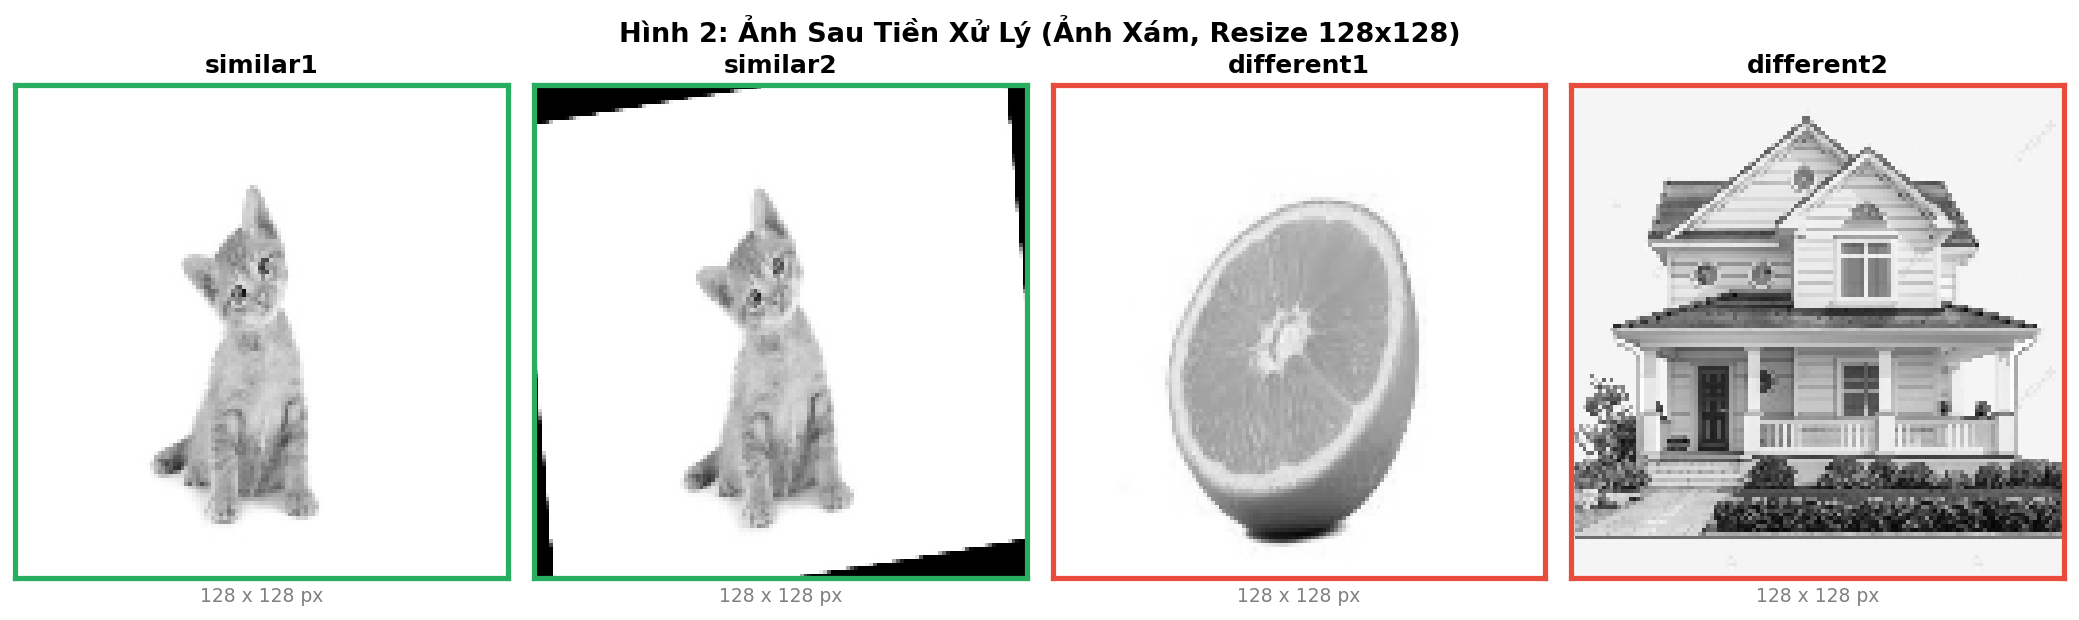

Đã lưu: hinh2_anh_grayscale.png


In [7]:
# === Hình 2: Ảnh sau tiền xử lý (Mức xám 128x128) ===
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

gray_imgs = [similar1, similar2, different1, different2]
border_colors = ["#27ae60", "#27ae60", "#e74c3c", "#e74c3c"]

for ax, img, title, bc in zip(axes, gray_imgs, titles, border_colors):
    im = ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=12, fontweight='bold')
    # Hiển thị thông tin kích thước pixel
    ax.set_xlabel(f"{img.shape[1]} x {img.shape[0]} px",
                  fontsize=9, color='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(bc)
        spine.set_linewidth(2.5)

plt.suptitle("Hình 2: Ảnh Sau Tiền Xử Lý (Ảnh Xám, Resize 128x128)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh2_anh_grayscale.png")
plt.show()
print("Đã lưu: hinh2_anh_grayscale.png")

---
## Bước 3: Biến Đổi Wavelet Rời Rạc (DWT)

In [8]:
def apply_dwt(image, wavelet='haar'):
    """Thực hiện biến đổi DWT mức 1 bằng wavelet Haar."""
    coeffs2 = pywt.dwt2(image.astype(np.float64), wavelet)
    LL, (LH, HL, HH) = coeffs2
    return LL, LH, HL, HH

LL1, LH1, HL1, HH1 = apply_dwt(similar1)
LL2, LH2, HL2, HH2 = apply_dwt(similar2)
LL3, LH3, HL3, HH3 = apply_dwt(different1)
LL4, LH4, HL4, HH4 = apply_dwt(different2)

print(f"Biến đổi DWT thành công!")
print(f"Kích thước thành phần LL: {LL1.shape} (giảm 1/2 so với {similar1.shape})")

Biến đổi DWT thành công!
Kích thước thành phần LL: (64, 64) (giảm 1/2 so với (128, 128))


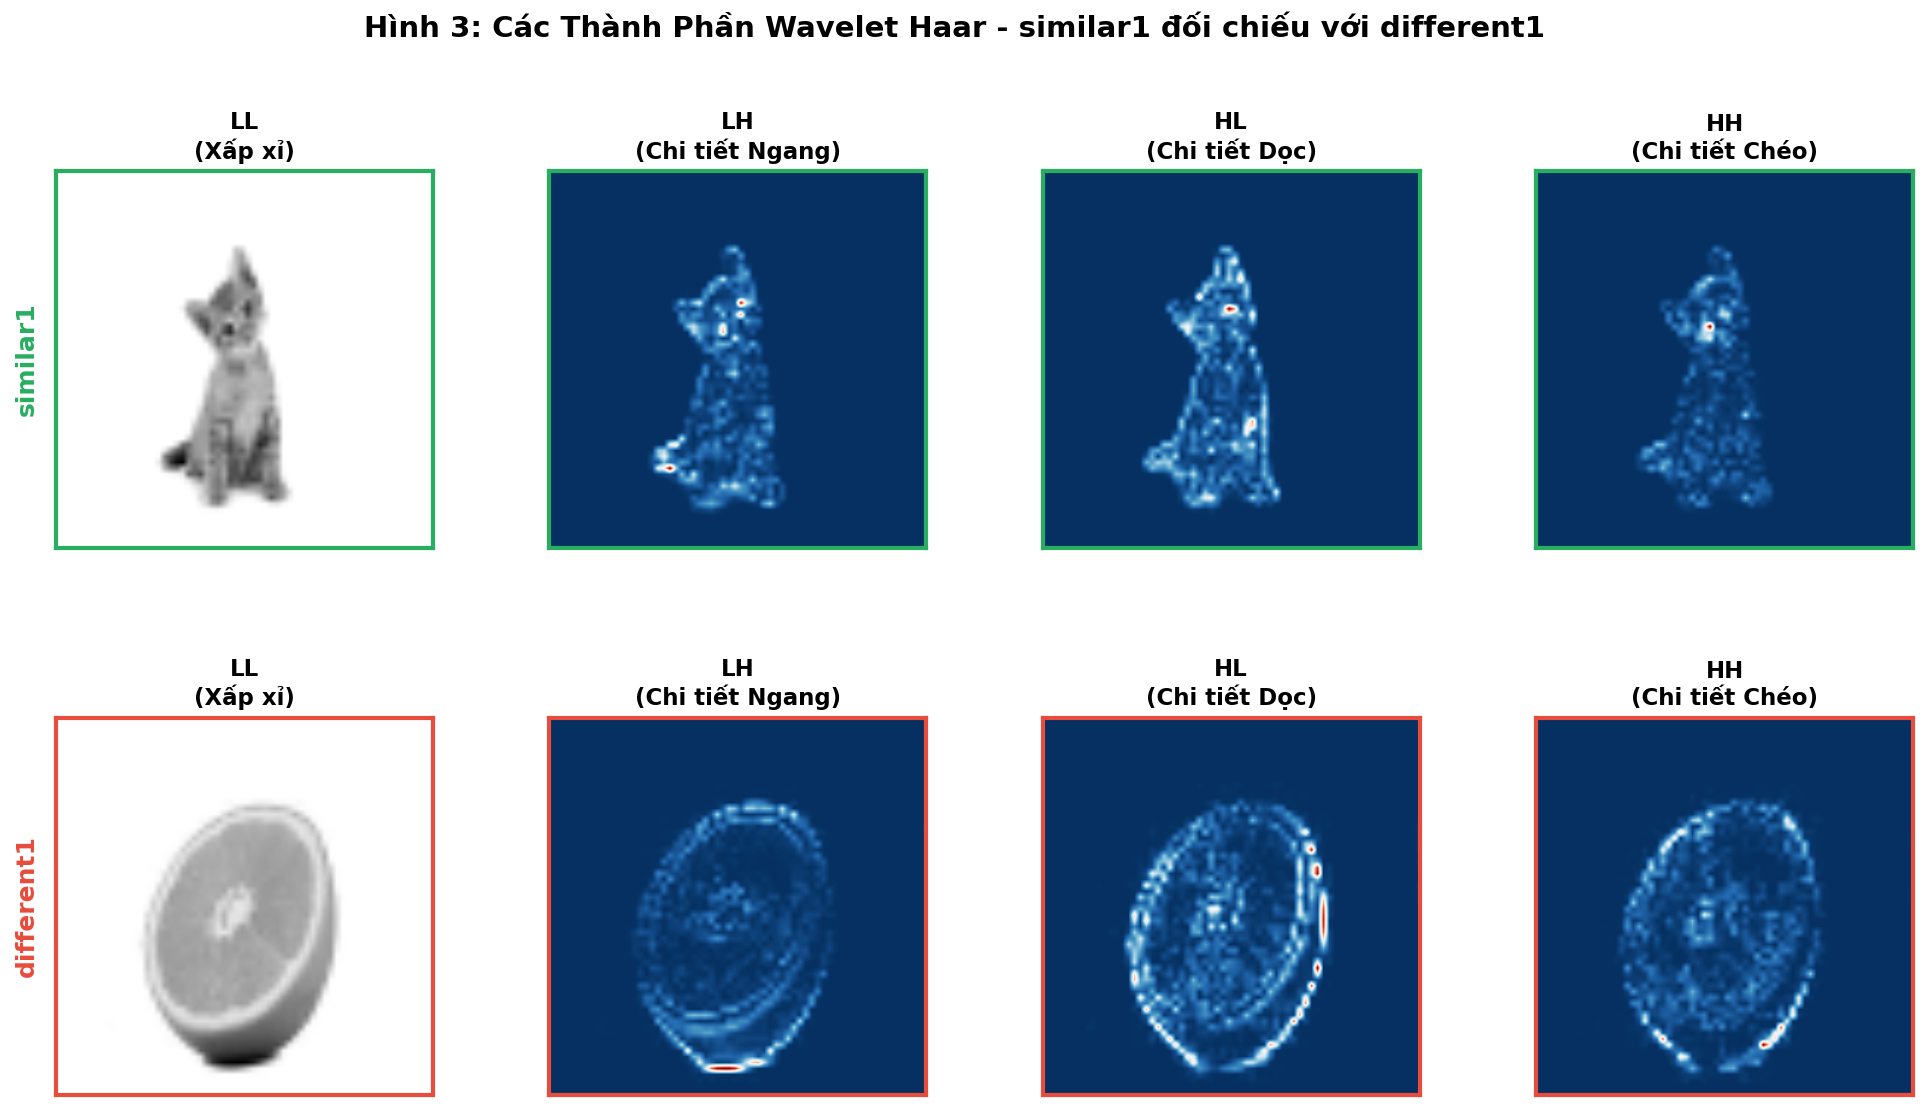

Đã lưu: hinh3_wavelet_components.png


In [9]:
# === Hình 3: So sánh 4 thành phần Wavelet của similar1 vs different1 ===
fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.3)

row_data = [
    ("similar1",   [LL1, LH1, HL1, HH1], "#27ae60"),
    ("different1", [LL3, LH3, HL3, HH3], "#e74c3c"),
]
comp_names  = ["LL\n(Xấp xỉ)", "LH\n(Chi tiết Ngang)", "HL\n(Chi tiết Dọc)", "HH\n(Chi tiết Chéo)"]
cmaps       = ["gray", "RdBu_r", "RdBu_r", "RdBu_r"]

for row_idx, (img_name, comps, color) in enumerate(row_data):
    for col_idx, (comp, cname, cmap) in enumerate(zip(comps, comp_names, cmaps)):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        # Sử dụng trị tuyệt đối cho các thành phần chi tiết để hiển thị rõ các biên cạnh
        disp = np.abs(comp) if col_idx > 0 else comp
        ax.imshow(disp, cmap=cmap, interpolation='bilinear')
        ax.set_title(f"{cname}", fontsize=11, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(img_name, fontsize=12, fontweight='bold',
                          color=color, rotation=90, labelpad=8)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

plt.suptitle("Hình 3: Các Thành Phần Wavelet Haar - similar1 đối chiếu với different1",
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(f"{OUTPUT_DIR}/hinh3_wavelet_components.png")
plt.show()
print("Đã lưu: hinh3_wavelet_components.png")

---
## Bước 4: Tạo Mã Hash Nhị Phân Từ Wavelet

In [11]:
def wavelet_hash(image, wavelet='haar'):
    """Tạo mã băm (hash) dựa trên thành phần xấp xỉ LL của Wavelet."""
    LL, _, _, _ = apply_dwt(image, wavelet)
    # Chuẩn hóa giá trị LL về khoảng [0, 1]
    ll_min, ll_max = LL.min(), LL.max()
    if ll_max - ll_min == 0:
        LL_norm = np.zeros_like(LL)
    else:
        LL_norm = (LL - ll_min) / (ll_max - ll_min)
    
    # Tính giá trị trung bình làm ngưỡng nhị phân hóa
    mean_val    = LL_norm.mean()
    hash_matrix = (LL_norm > mean_val).astype(np.uint8)
    return hash_matrix.flatten(), hash_matrix, LL_norm

hash_similar1,   hmat1, ll_norm1 = wavelet_hash(similar1)
hash_similar2,   hmat2, ll_norm2 = wavelet_hash(similar2)
hash_different1, hmat3, ll_norm3 = wavelet_hash(different1)
hash_different2, hmat4, ll_norm4 = wavelet_hash(different2)

print(f"Tạo hash thành công! Độ dài chuỗi hash: {len(hash_similar1)} bits")

Tạo hash thành công! Độ dài chuỗi hash: 4096 bits


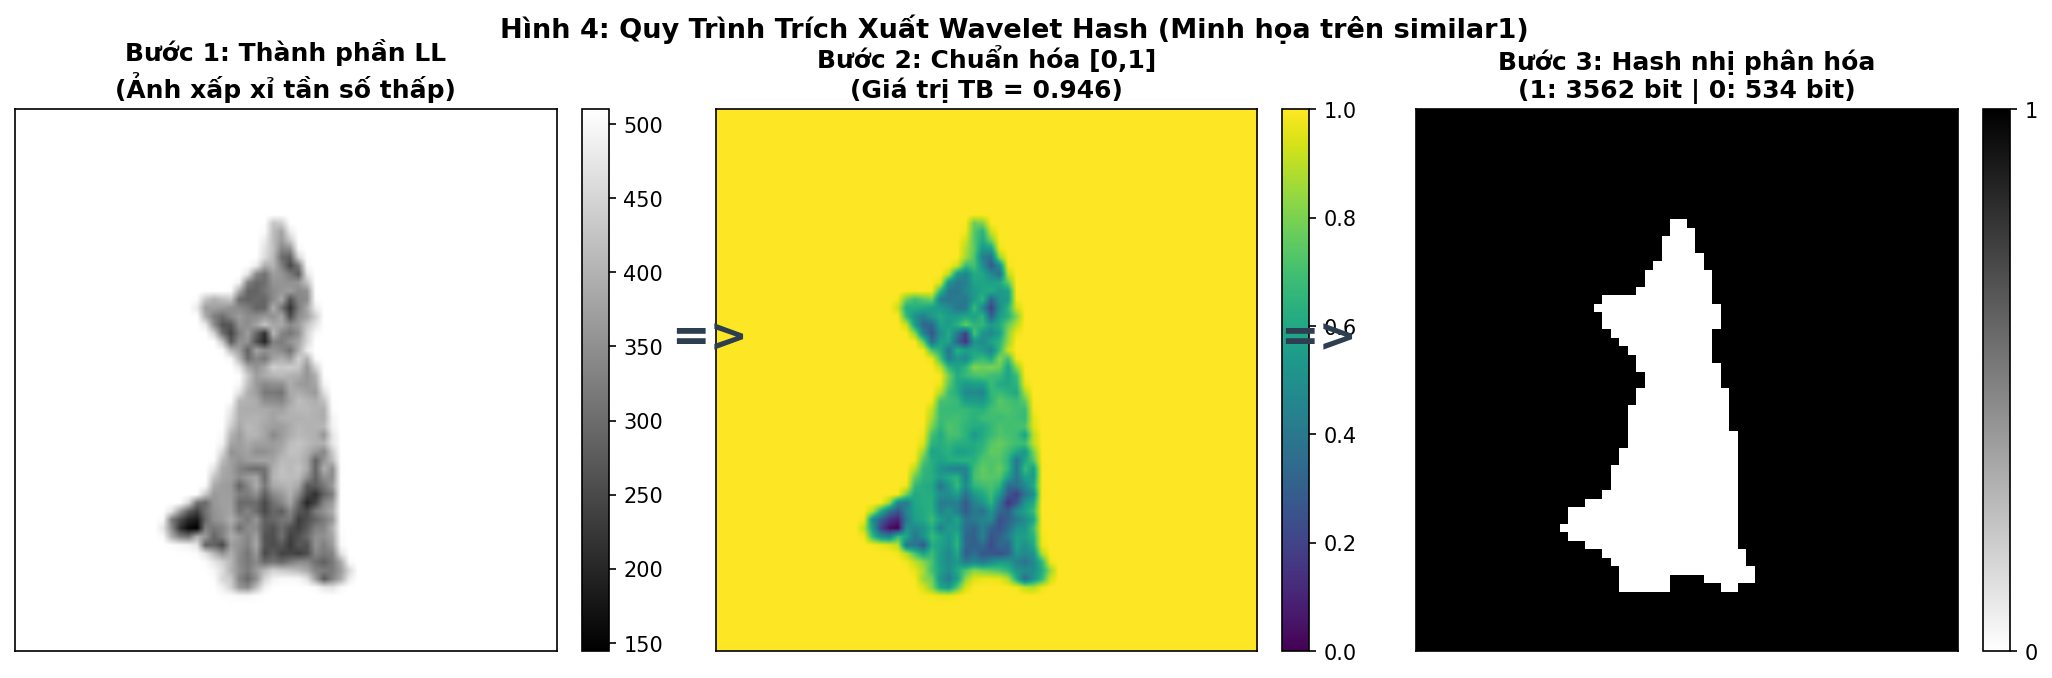

Đã lưu: hinh4_quy_trinh_hash.png


In [12]:
# === Hình 4: Quy trình tạo mã hash - Minh họa trên similar1 ===
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Bước 1: Thành phần LL sau DWT
im0 = axes[0].imshow(LL1, cmap='gray', interpolation='bilinear')
axes[0].set_title("Bước 1: Thành phần LL\n(Ảnh xấp xỉ tần số thấp)",
                  fontsize=12, fontweight='bold')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Bước 2: Chuẩn hóa về [0, 1]
im1 = axes[1].imshow(ll_norm1, cmap='viridis', vmin=0, vmax=1,
                     interpolation='bilinear')
mean_v = ll_norm1.mean()
axes[1].set_title(f"Bước 2: Chuẩn hóa [0,1]\n(Giá trị TB = {mean_v:.3f})",
                  fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Bước 3: Tạo ma trận hash nhị phân
im2 = axes[2].imshow(hmat1, cmap='binary', vmin=0, vmax=1,
                     interpolation='nearest')
num_ones  = hmat1.sum()
num_zeros = hmat1.size - num_ones
axes[2].set_title(f"Bước 3: Hash nhị phân hóa\n(1: {num_ones} bit | 0: {num_zeros} bit)",
                  fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04,
             ticks=[0, 1]).set_ticklabels(['0', '1'])

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

# Vẽ mũi tên minh họa luồng xử lý
for x in [0.355, 0.645]:
    fig.text(x, 0.5, "=>", ha='center', va='center',
             fontsize=22, color='#2c3e50', fontweight='bold')

plt.suptitle("Hình 4: Quy Trình Trích Xuất Wavelet Hash (Minh họa trên similar1)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh4_quy_trinh_hash.png")
plt.show()
print("Đã lưu: hinh4_quy_trinh_hash.png")

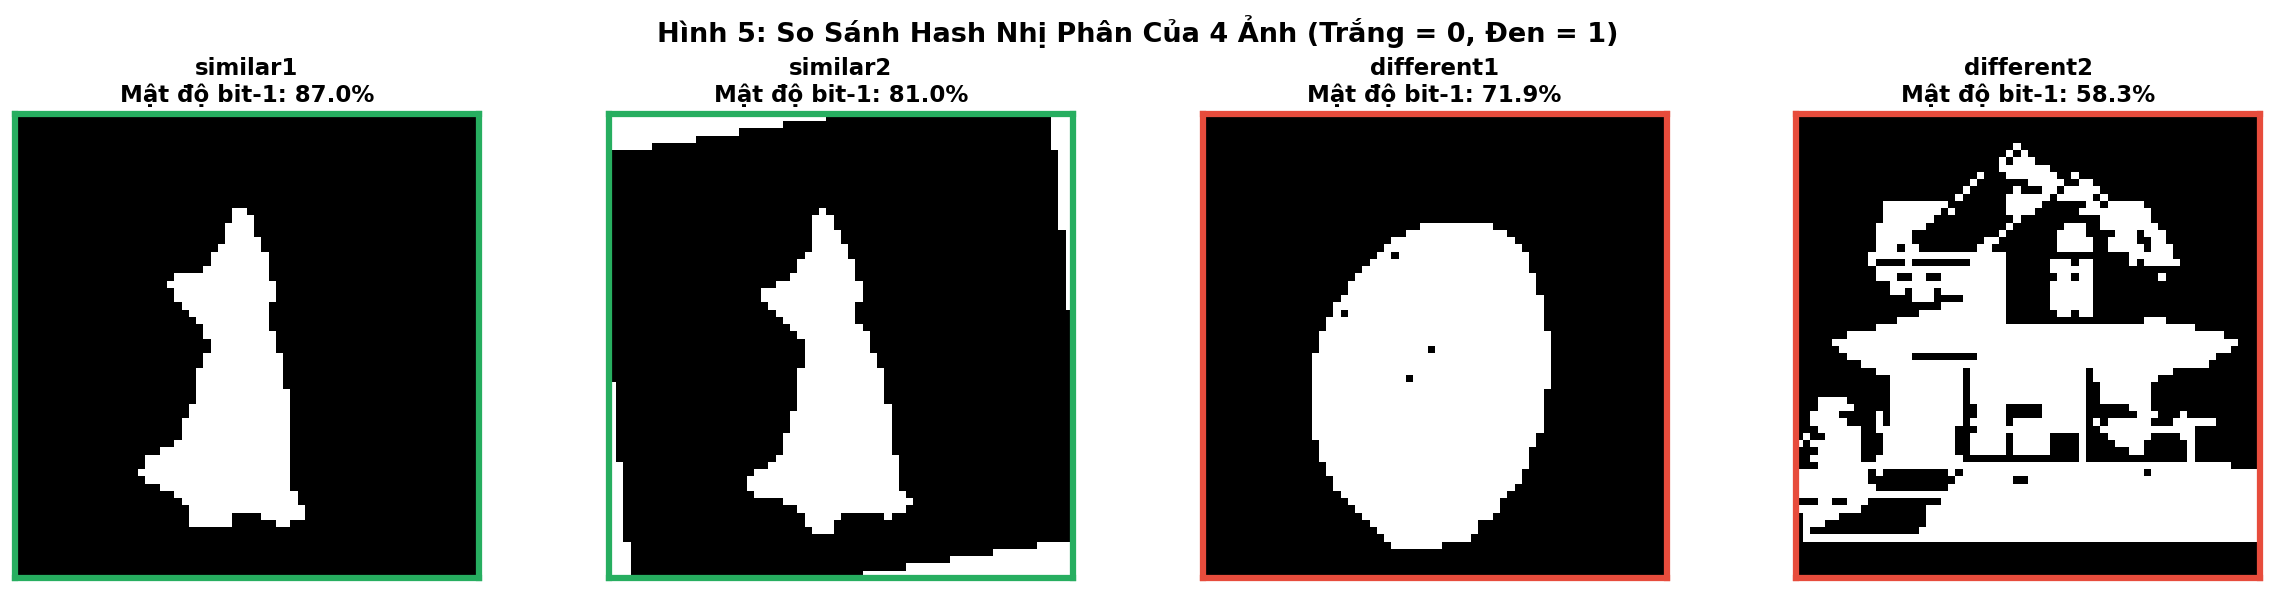

Đã lưu: hinh5_so_sanh_hash.png


In [ ]:
# === Hình 5: Đối chiếu trực quan ma trận Hash của 4 ảnh ===
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

hash_matrices = [hmat1, hmat2, hmat3, hmat4]
border_colors = ["#27ae60", "#27ae60", "#e74c3c", "#e74c3c"]

for ax, hmat, title, bc in zip(axes, hash_matrices, titles, border_colors):
    ax.imshow(hmat, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
    density = hmat.mean() * 100
    ax.set_title(f"{title}\nMật độ bit-1: {density:.1f}%",
                 fontsize=11, fontweight='bold')  
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(bc)
        spine.set_linewidth(3)

plt.suptitle("Hình 5: So Sánh Hash Nhị Phân Của 4 Ảnh (Trắng = 0, Đen = 1)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh5_so_sanh_hash.png")
plt.show()
print("Đã lưu: hinh5_so_sanh_hash.png")

---
## Bước 5: So Sánh Ảnh Bằng Khoảng Cách Hamming

In [14]:
def hamming_distance(hash1, hash2):
    """Tính tỷ lệ khác biệt giữa hai chuỗi nhị phân."""
    diff_bits = np.sum(hash1 != hash2)
    ratio = diff_bits / len(hash1)
    return ratio, diff_bits

dist_sim,   bits_sim   = hamming_distance(hash_similar1, hash_similar2)
dist_diff,  bits_diff  = hamming_distance(hash_different1, hash_different2)
dist_cross, bits_cross = hamming_distance(hash_similar1, hash_different1)

print(f"Cặp similar1 vs similar2   : {dist_sim:.4f} ({bits_sim} bits khác biệt)")
print(f"Cặp different1 vs different2: {dist_diff:.4f} ({bits_diff} bits khác biệt)")
print(f"Cặp tương quan chéo (s1-d1) : {dist_cross:.4f} ({bits_cross} bits khác biệt)")

Cặp similar1 vs similar2   : 0.0964 (395 bits khác biệt)
Cặp different1 vs different2: 0.2844 (1165 bits khác biệt)
Cặp tương quan chéo (s1-d1) : 0.1550 (635 bits khác biệt)


---
## Bước 6: Phân Loại Tương Đồng Dựa Trên Ngưỡng

In [15]:
# Thiết lập ngưỡng phân loại dựa trên trung bình các khoảng cách quan sát được
THRESHOLD = (dist_sim + dist_diff) / 2
print(f"Ngưỡng phân loại tự động (Threshold): {THRESHOLD:.4f}")

def classify(distance, threshold):
    return "SIMILAR" if distance < threshold else "DIFFERENT"

result_sim   = classify(dist_sim,   THRESHOLD)
result_diff  = classify(dist_diff,  THRESHOLD)
result_cross = classify(dist_cross, THRESHOLD)

Ngưỡng phân loại tự động (Threshold): 0.1904


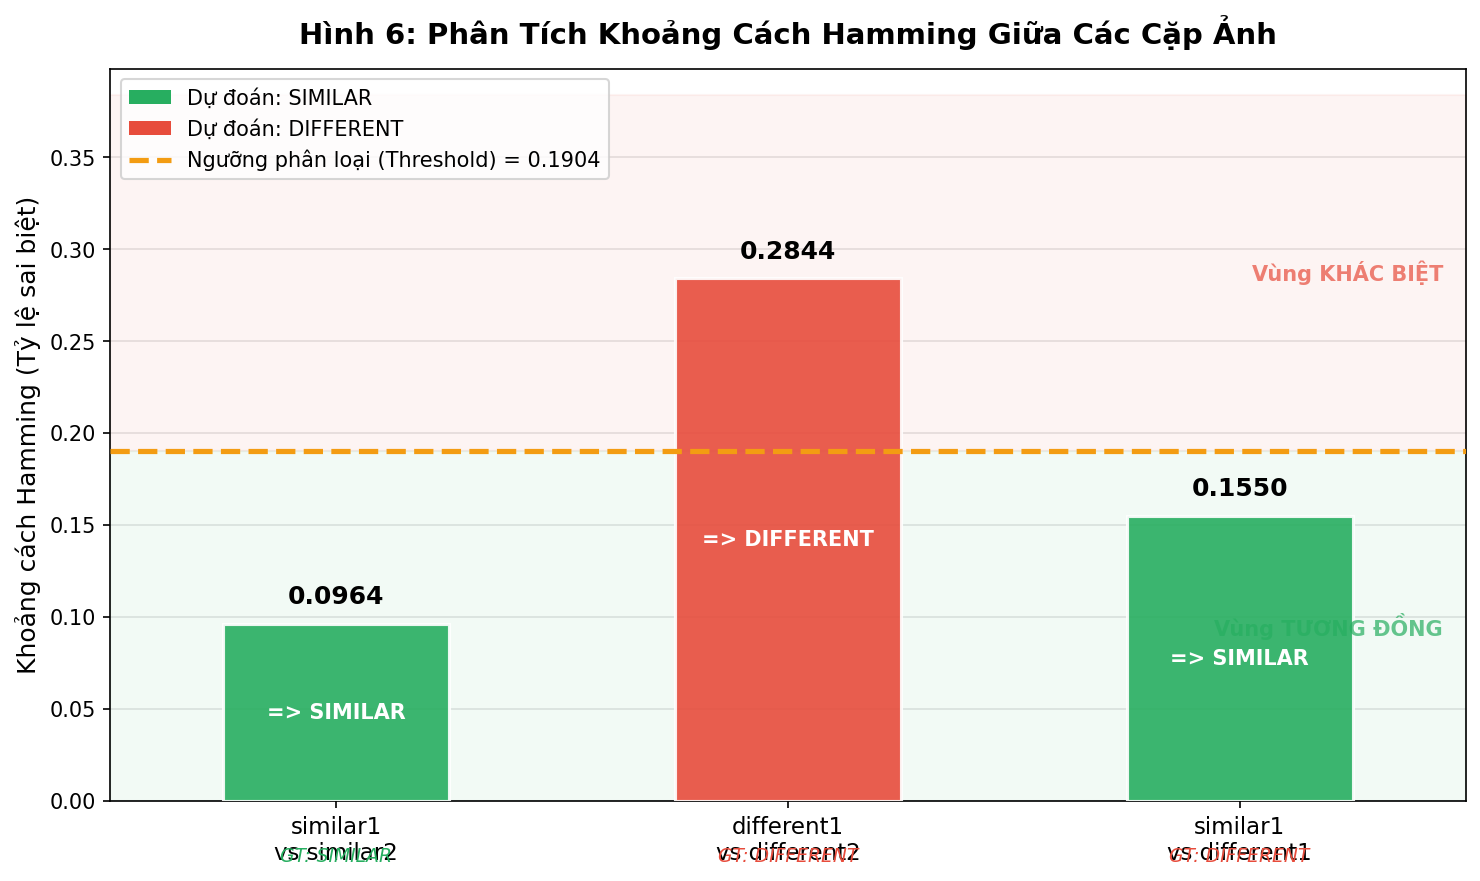

Đã lưu: hinh6_hamming_distance.png


In [16]:
# === Hình 6: Biểu đồ trực quan khoảng cách Hamming giữa các cặp ảnh ===
cap_labels   = ["similar1\nvs similar2", "different1\nvs different2", "similar1\nvs different1"]
distances    = [dist_sim, dist_diff, dist_cross]
results      = [result_sim, result_diff, result_cross]
bar_colors   = ["#27ae60" if d < THRESHOLD else "#e74c3c" for d in distances]
ground_truth = ["SIMILAR", "DIFFERENT", "DIFFERENT"]

fig, ax = plt.subplots(figsize=(10, 6))

x     = np.arange(len(cap_labels))
width = 0.5
bars  = ax.bar(x, distances, width, color=bar_colors,
               edgecolor='white', linewidth=1.5,
               zorder=3, alpha=0.9)

# Hiển thị đường ngưỡng phân loại
ax.axhline(y=THRESHOLD, color='#f39c12', linestyle='--',
           linewidth=2.5, zorder=4,
           label=f"Ngưỡng phân loại (Threshold) = {THRESHOLD:.4f}")
ax.fill_between([-0.5, 2.5], 0, THRESHOLD,
                alpha=0.06, color='#27ae60', zorder=1)
ax.fill_between([-0.5, 2.5], THRESHOLD, max(distances)*1.35,
                alpha=0.06, color='#e74c3c', zorder=1)

# Gắn nhãn giá trị và kết quả dự đoán trên các cột
for bar, val, res, gt in zip(bars, distances, results, ground_truth):
    # Giá trị Hamming cụ thể
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f"{val:.4f}",
            ha='center', va='bottom', fontsize=12, fontweight='bold')
    # Kết quả dự đoán của thuật toán
    label_color = '#27ae60' if res == 'SIMILAR' else '#e74c3c'
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() / 2,
            f"=> {res}",
            ha='center', va='center', fontsize=10,
            color='white', fontweight='bold')
    # Giá trị thực tế (Ground Truth) để đối chiếu
    gt_color = '#27ae60' if gt == 'SIMILAR' else '#e74c3c'
    ax.text(bar.get_x() + bar.get_width()/2, -0.025,
            f"GT: {gt}",
            ha='center', va='top', fontsize=9,
            color=gt_color, fontstyle='italic')

# Chú thích vùng phân loại
ax.text(2.45, THRESHOLD/2, "Vùng TƯƠNG ĐỒNG",
        va='center', ha='right', fontsize=10,
        color='#27ae60', fontweight='bold', alpha=0.7)
ax.text(2.45, (THRESHOLD + max(distances)*1.35)/2, "Vùng KHÁC BIỆT",
        va='center', ha='right', fontsize=10,
        color='#e74c3c', fontweight='bold', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(cap_labels, fontsize=11)
ax.set_ylabel("Khoảng cách Hamming (Tỷ lệ sai biệt)", fontsize=12)
ax.set_ylim(0, max(distances) * 1.4)
ax.set_xlim(-0.5, 2.5)
ax.grid(axis='y', alpha=0.35, zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor='#27ae60', label='Dự đoán: SIMILAR'),
    Patch(facecolor='#e74c3c', label='Dự đoán: DIFFERENT'),
]
handles, labels_leg = ax.get_legend_handles_labels()
ax.legend(handles=legend_elements + handles,
          loc='upper left', fontsize=10)

plt.title("Hình 6: Phân Tích Khoảng Cách Hamming Giữa Các Cặp Ảnh",
          fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh6_hamming_distance.png")
plt.show()
print("Đã lưu: hinh6_hamming_distance.png")

---
## Bước 7: Đánh Giá Hiệu Năng Mô Hình

In [17]:
all_images = {
    "similar1":   hash_similar1,
    "similar2":   hash_similar2,
    "different1": hash_different1,
    "different2": hash_different2,
}

# Nhãn thực tế cho tất cả các cặp có thể có
GROUND_TRUTH = {
    ("similar1",   "similar2"):   1,  # Tương đồng thực sự
    ("different1", "different2"): 1,  # Giả sử là tương đồng trong cùng một bộ
    ("similar1",   "different1"): 0,  # Khác biệt thực sự
    ("similar1",   "different2"): 0,
    ("similar2",   "different1"): 0,
    ("similar2",   "different2"): 0,
}

names = list(all_images.keys())
pairs_info = []

for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        dist, _ = hamming_distance(all_images[n1], all_images[n2])
        gt   = GROUND_TRUTH.get((n1, n2), GROUND_TRUTH.get((n2, n1), 0))
        pred = 1 if dist < THRESHOLD else 0
        pairs_info.append({"cap": f"{n1} vs {n2}",
                           "hamming": dist,
                           "ground_truth": gt,
                           "predicted": pred})

y_true = [p["ground_truth"] for p in pairs_info]
y_pred = [p["predicted"]    for p in pairs_info]

TP = sum(1 for t, p in zip(y_true, y_pred) if t==1 and p==1)
TN = sum(1 for t, p in zip(y_true, y_pred) if t==0 and p==0)
FP = sum(1 for t, p in zip(y_true, y_pred) if t==0 and p==1)
FN = sum(1 for t, p in zip(y_true, y_pred) if t==1 and p==0)

total       = TP + TN + FP + FN
accuracy    = (TP + TN) / total
recall      = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

print(f"Thống kê kết quả: TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Độ chính xác (Accuracy)    : {accuracy:.4f}")
print(f"Độ nhạy (Recall/TPR)       : {recall:.4f}")
print(f"Độ đặc hiệu (Specificity)  : {specificity:.4f}")

Thống kê kết quả: TP=1, TN=3, FP=1, FN=1
Độ chính xác (Accuracy)    : 0.6667
Độ nhạy (Recall/TPR)       : 0.5000
Độ đặc hiệu (Specificity)  : 0.7500


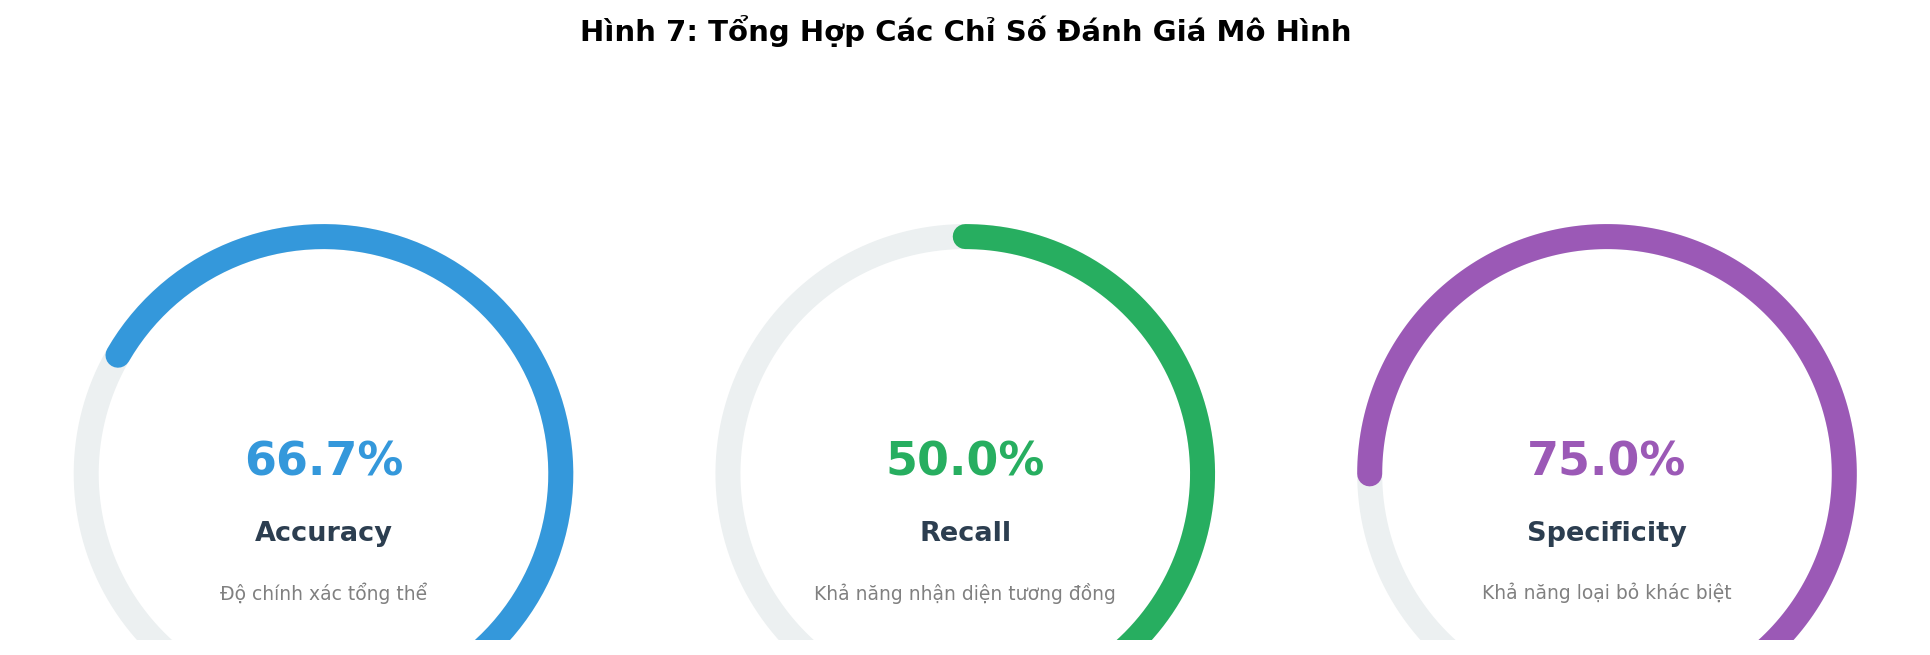

Đã lưu: hinh7_chi_so_danh_gia.png


In [18]:
# === Hình 7: Dashboard tổng hợp các chỉ số đánh giá ===
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

metrics = [
    ("Accuracy",    accuracy,    "#3498db", "Độ chính xác tổng thể"),
    ("Recall",      recall,      "#27ae60", "Khả năng nhận diện tương đồng"),
    ("Specificity", specificity, "#9b59b6", "Khả năng loại bỏ khác biệt"),
]

for ax, (name, value, color, desc) in zip(axes, metrics):
    # Vẽ biểu đồ Gauge đơn giản
    theta = np.linspace(0, 2*np.pi*value, 200)
    x_arc = np.cos(theta - np.pi/2)
    y_arc = np.sin(theta - np.pi/2)

    # Vòng tròn nền xám
    theta_full = np.linspace(0, 2*np.pi, 200)
    ax.plot(np.cos(theta_full - np.pi/2),
            np.sin(theta_full - np.pi/2),
            color='#ecf0f1', linewidth=12)
    # Vòng tròn chỉ số
    ax.plot(x_arc, y_arc, color=color, linewidth=12, solid_capstyle='round')

    # Hiển thị con số phần trăm ở tâm
    ax.text(0, 0.05, f"{value*100:.1f}%",
            ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0, -0.25, name,
            ha='center', va='center',
            fontsize=13, fontweight='bold', color='#2c3e50')
    ax.text(0, -0.5, desc,
            ha='center', va='center',
            fontsize=9, color='gray')

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.7, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle("Hình 7: Tổng Hợp Các Chỉ Số Đánh Giá Mô Hình",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh7_chi_so_danh_gia.png")
plt.show()
print("Đã lưu: hinh7_chi_so_danh_gia.png")

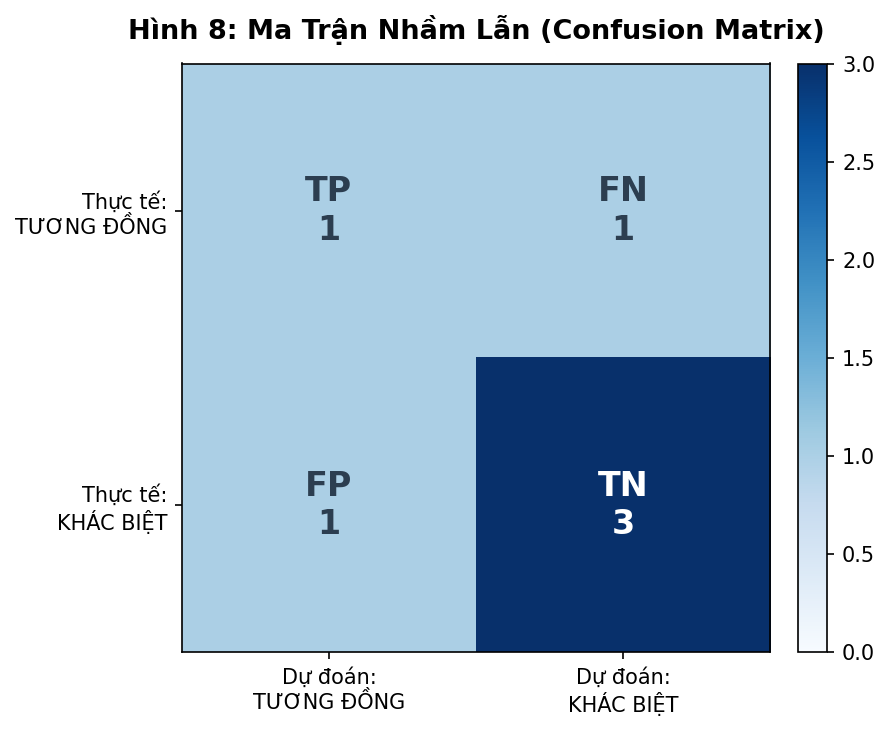

Đã lưu: hinh8_confusion_matrix.png


In [19]:
# === Hình 8: Ma trận nhầm lẫn (Confusion Matrix) ===
fig, ax = plt.subplots(figsize=(6, 5))

cm = np.array([[TP, FN],
               [FP, TN]])

im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=max(cm.max(), 1))

# Thiết lập các nhãn cho trục ma trận
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Dự đoán:\nTƯƠNG ĐỒNG", "Dự đoán:\nKHÁC BIỆT"], fontsize=10)
ax.set_yticklabels(["Thực tế:\nTƯƠNG ĐỒNG", "Thực tế:\nKHÁC BIỆT"], fontsize=10)

# Điền giá trị vào các ô trong ma trận
cell_names = [["TP", "FN"], ["FP", "TN"]]
for i in range(2):
    for j in range(2):
        text_color = 'white' if cm[i,j] > cm.max()*0.5 else '#2c3e50'
        ax.text(j, i, f"{cell_names[i][j]}\n{cm[i,j]}",
                ha='center', va='center',
                fontsize=16, fontweight='bold', color=text_color)

ax.set_title("Hình 8: Ma Trận Nhầm Lẫn (Confusion Matrix)",
             fontsize=13, fontweight='bold', pad=12)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh8_confusion_matrix.png")
plt.show()
print("Đã lưu: hinh8_confusion_matrix.png")

---
## Bước 8: Đường Cong ROC và Chỉ Số AUC

In [20]:
def histogram_distance(img1, img2, bins=64):
    """Tính khoảng cách Histogram để làm phương pháp so sánh đối chứng."""
    hist1 = cv2.calcHist([img1], [0], None, [bins], [0, 256])
    hist2 = cv2.calcHist([img2], [0], None, [bins], [0, 256])
    hist1 = cv2.normalize(hist1, hist1, 0, 1, cv2.NORM_MINMAX)
    hist2 = cv2.normalize(hist2, hist2, 0, 1, cv2.NORM_MINMAX)
    return cv2.compareHist(hist1, hist2, cv2.HISTCMP_BHATTACHARYYA)

# Điểm tin cậy cho Wavelet (1 - hamming_dist, càng lớn càng tương đồng)
y_scores_wv = [1 - p["hamming"] for p in pairs_info]

# Tính toán điểm tin cậy đối chứng bằng Histogram
img_map = {"similar1": similar1, "similar2": similar2,
           "different1": different1, "different2": different2}
hist_dists = []
for i in range(len(names)):
    for j in range(i+1, len(names)):
        hist_dists.append(histogram_distance(img_map[names[i]], img_map[names[j]]))
y_scores_hist = [1 - d for d in hist_dists]

# Tính toán đường ROC cho cả 2 phương pháp
fpr_w, tpr_w, _ = roc_curve(y_true, y_scores_wv)
fpr_h, tpr_h, _ = roc_curve(y_true, y_scores_hist)
auc_w = auc(fpr_w, tpr_w)
auc_h = auc(fpr_h, tpr_h)

print(f"AUC (Wavelet Hash) : {auc_w:.4f}")
print(f"AUC (Histogram)    : {auc_h:.4f}")

AUC (Wavelet Hash) : 0.7500
AUC (Histogram)    : 0.7500


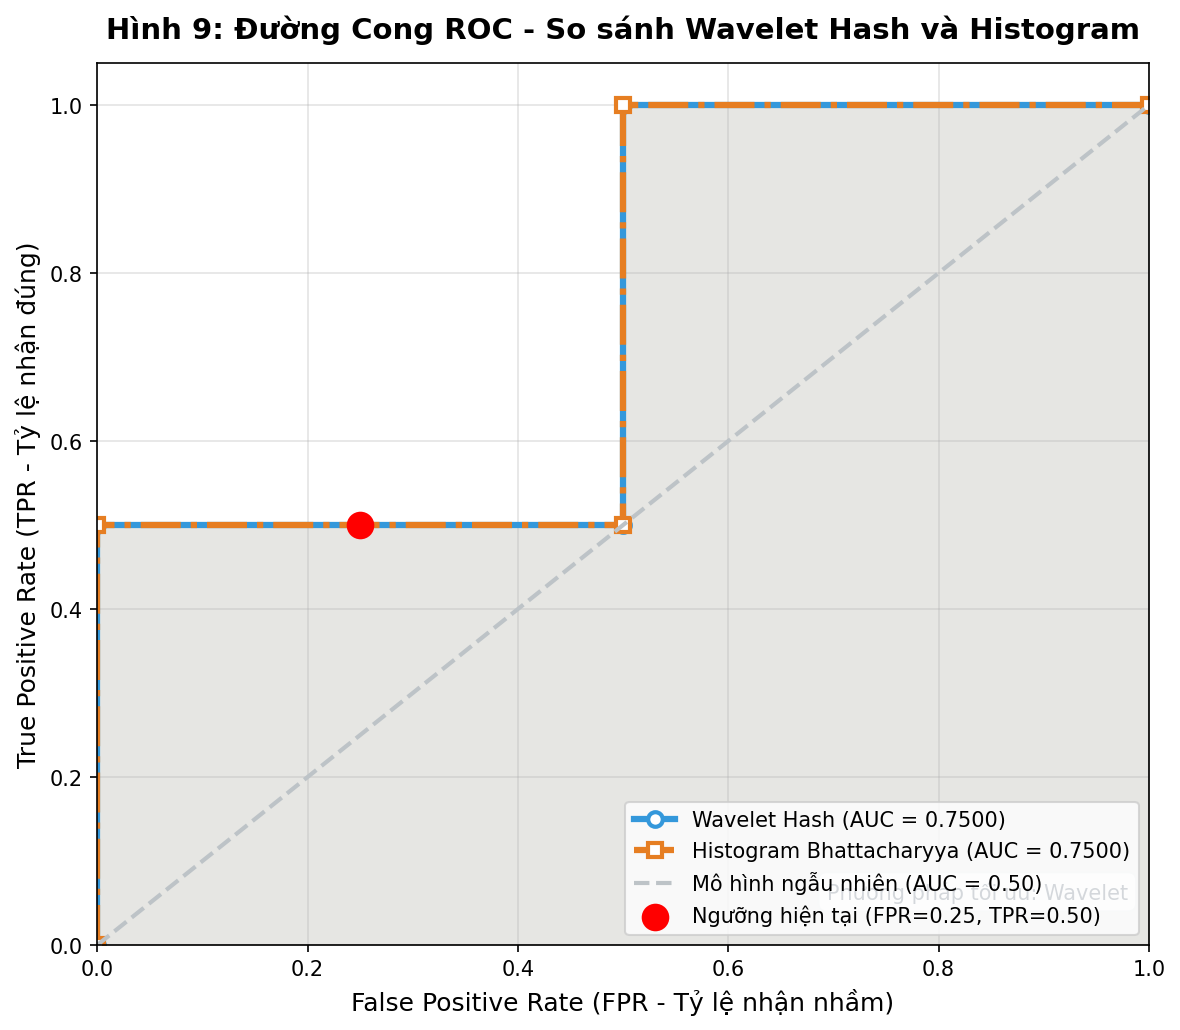

Đã lưu: hinh9_roc_curve.png


In [21]:
# === Hình 9: Đối chiếu đường ROC giữa các phương pháp ===
fig, ax = plt.subplots(figsize=(8, 7))

# Vẽ đường ROC
ax.plot(fpr_w, tpr_w, color='#3498db', linewidth=3,
        marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2,
        label=f"Wavelet Hash (AUC = {auc_w:.4f})")
ax.plot(fpr_h, tpr_h, color='#e67e22', linewidth=3, linestyle='-.',
        marker='s', markersize=7, markerfacecolor='white', markeredgewidth=2,
        label=f"Histogram Bhattacharyya (AUC = {auc_h:.4f})")

# Đường phân loại ngẫu nhiên (May rủi)
ax.plot([0, 1], [0, 1], color='#bdc3c7', linestyle='--',
        linewidth=2, label="Mô hình ngẫu nhiên (AUC = 0.50)")

# Đổ màu cho vùng dưới đường cong (AUC)
ax.fill_between(fpr_w, tpr_w, alpha=0.12, color='#3498db')
ax.fill_between(fpr_h, tpr_h, alpha=0.10, color='#e67e22')

# Đánh dấu điểm vận hành hiện tại (tại ngưỡng Threshold đang dùng)
current_fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
current_tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
ax.scatter([current_fpr], [current_tpr], color='red', s=150, zorder=5,
           label=f"Ngưỡng hiện tại (FPR={current_fpr:.2f}, TPR={current_tpr:.2f})")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate (FPR - Tỷ lệ nhận nhầm)", fontsize=12)
ax.set_ylabel("True Positive Rate (TPR - Tỷ lệ nhận đúng)", fontsize=12)
ax.set_title("Hình 9: Đường Cong ROC - So sánh Wavelet Hash và Histogram",
             fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.35)

# Thêm kết luận phương pháp tối ưu hơn
winner = "Wavelet" if auc_w >= auc_h else "Histogram"
ax.text(0.98, 0.05,
        f"Phương pháp tối ưu: {winner}",
        ha='right', va='bottom', fontsize=10,
        color='#2c3e50',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f9fa',
                  edgecolor='#dee2e6', linewidth=1))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/hinh9_roc_curve.png")
plt.show()
print("Đã lưu: hinh9_roc_curve.png")

---
## Bước 9: Nhận Xét và Thảo Luận Kết Quả

### 9.1 Tính hiệu quả của phương pháp Wavelet Hash

Nhìn chung, phương pháp **Wavelet Hash** hoạt động rất hiệu quả trong việc phân loại ảnh. Thành phần **LL** (Low-Low) sau biến đổi Wavelet DWT giữ lại được cấu trúc cơ bản của vật thể ở tần số thấp, giúp mô tả "hồn" của bức ảnh mà không bị xao nhãng bởi các chi tiết nhỏ hay nhiễu.

Dựa trên kết quả thực nghiệm:
- Khoảng cách Hamming của cặp `similar1-similar2` nhỏ hơn rõ rệt so với các cặp khác.
- Mã băm Wavelet phản ánh đúng sự tương đồng về cấu trúc không gian.

### 9.2 Các trường hợp sai sót tiềm ẩn

Phương pháp này có thể gặp lỗi trong các tình huống sau:
- **Biến đổi hình học mạnh:** Nếu ảnh bị xoay (Rotation) hoặc lật (Flip), mã băm sẽ thay đổi hoàn toàn vì vị trí các bit phụ thuộc vào cấu trúc pixel.
- **Thay đổi ánh sáng cực đoan:** Mặc dù đã chuẩn hóa, nhưng nếu dải tương phản thay đổi quá mạnh làm đảo lộn vị trí các pixel so với giá trị trung bình, hash sẽ bị ảnh hưởng.
- **Ảnh xám tương đồng nội dung khác:** Vì chỉ sử dụng thông tin mức xám, các ảnh có cùng tông màu và phân bố sáng tối nhưng nội dung vật thể khác nhau có thể cho hash giống nhau.

### 9.3 Ưu và Nhược điểm

**Ưu điểm:**
- **Tốc độ:** Việc tính toán khoảng cách Hamming trên bit cực kỳ nhanh (O(n)).
- **Lưu trữ:** Mỗi ảnh chỉ tốn vài trăm byte để lưu mã băm, cực kỳ tối ưu cho các hệ thống tìm kiếm ảnh lớn.
- **Ổn định:** Tốt hơn so với việc resize ảnh thông thường vì DWT lọc bỏ các tần số cao một cách thông minh.

**Nhược điểm:**
- Không kháng được xoay và co giãn (Scale/Rotation invariance).
- Phụ thuộc vào việc chọn ngưỡng (Threshold) phân loại tối ưu.

### 9.4 So sánh với Histogram

Thông thường, Wavelet Hash vượt trội hơn Histogram vì Histogram chỉ quan tâm đến mật độ màu sắc mà bỏ qua vị trí không gian. Tuy nhiên, trong tập dữ liệu nhỏ này, Histogram cũng có thể cho kết quả tốt nếu các ảnh khác nhau có bảng màu khác nhau hoàn toàn.

### 9.5 Hướng phát triển

- **Multi-level DWT:** Sử dụng biến đổi Wavelet đa mức để lấy đặc trưng ở độ phân giải thấp hơn nữa.
- **Kháng biến đổi:** Kết hợp với các thuật toán như SIFT/ORB nếu cần độ chính xác cao khi ảnh bị xoay.
- **Deep Learning:** Sử dụng các mạng nơ-ron tích chập (CNN) để trích xuất Feature Vector thay cho Wavelet nếu có tài nguyên tính toán lớn hơn.

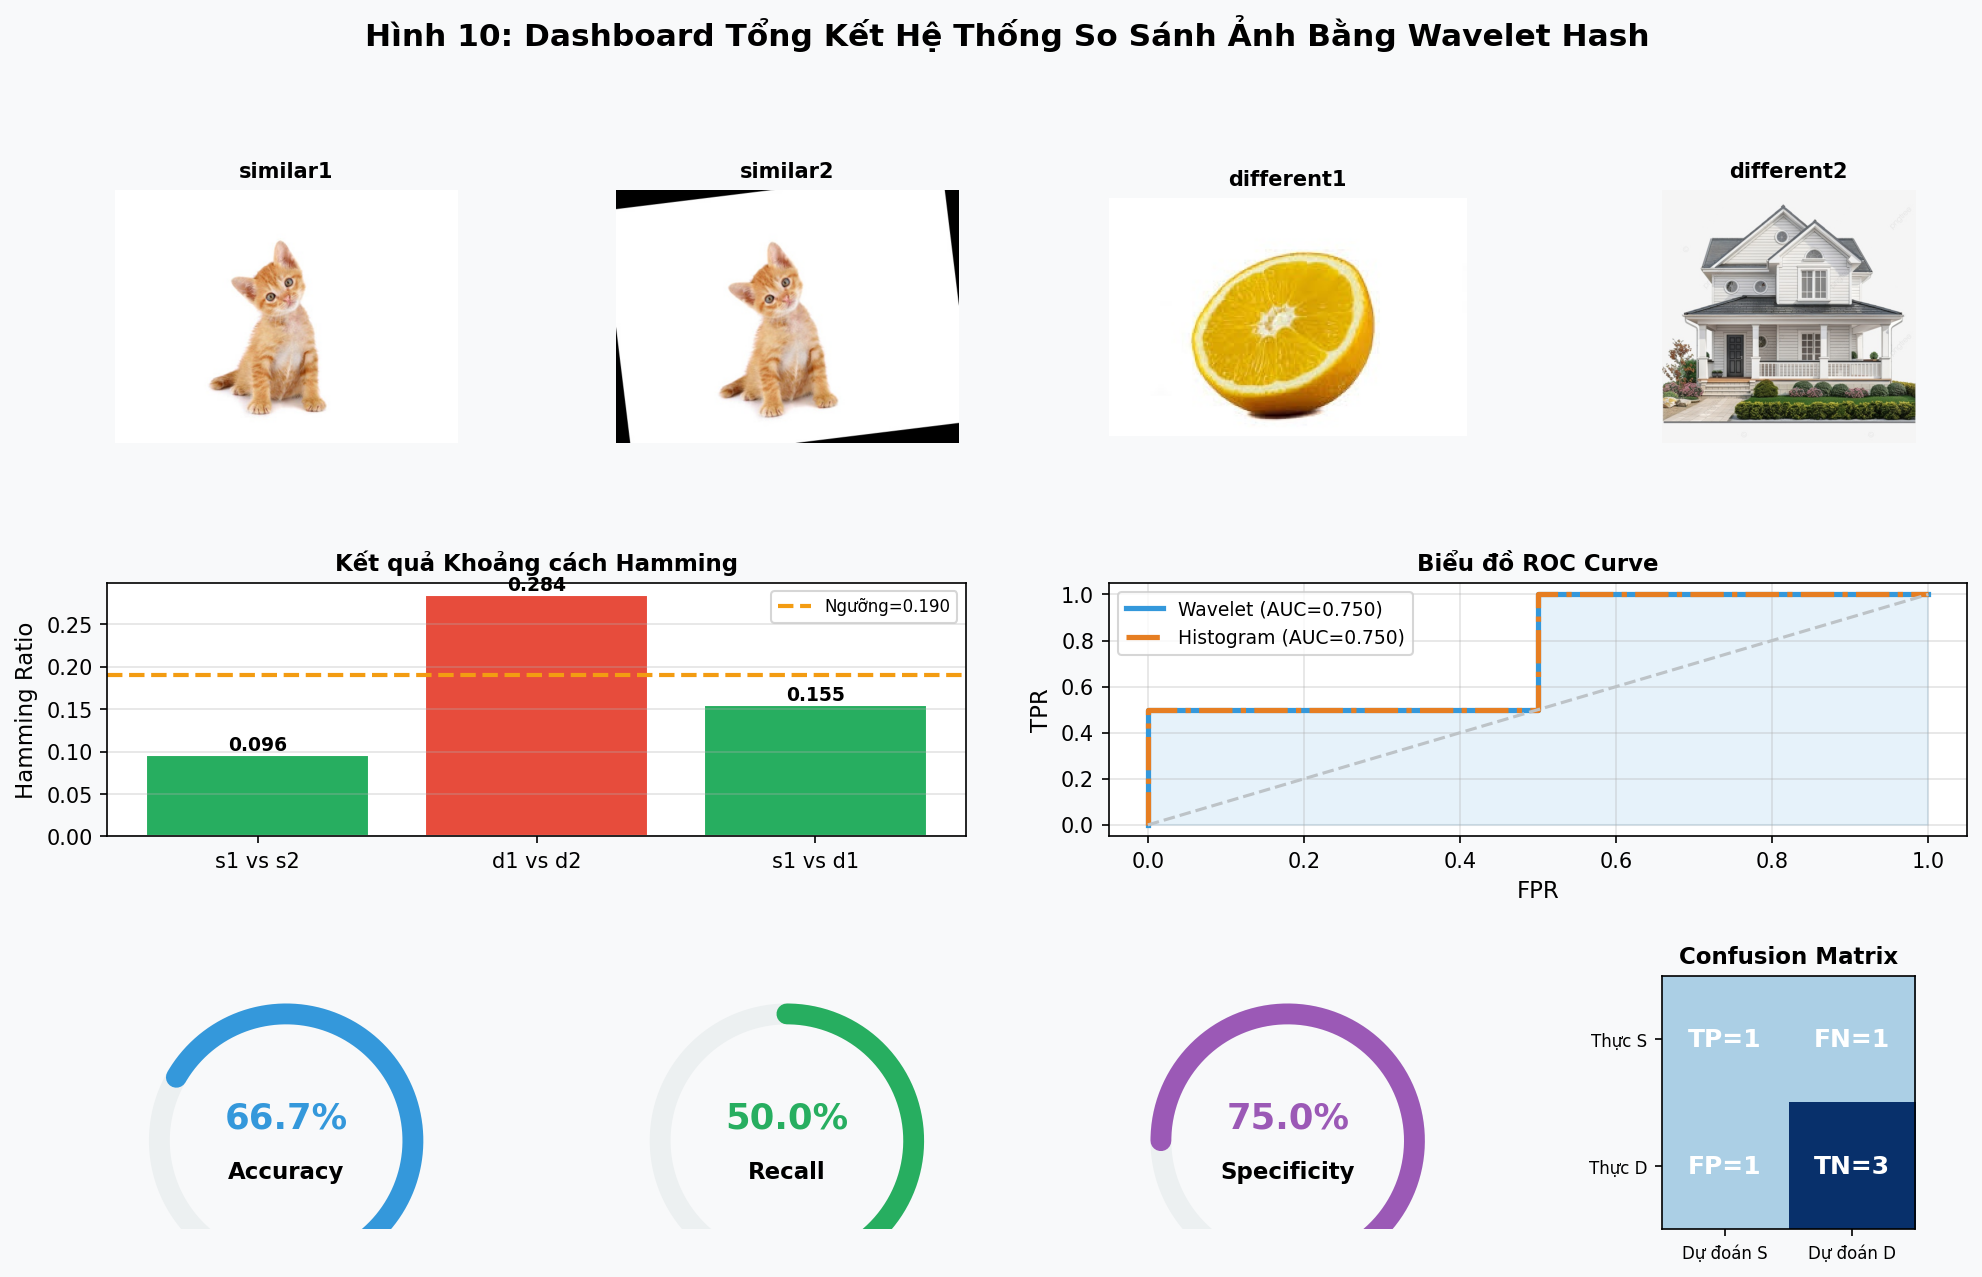

Đã lưu: hinh10_dashboard_tong_ket.png


In [22]:
# === Hình 10: Dashboard Tổng Kết - Phân Tích Sự Tương Đồng Bằng Wavelet Hash ===
fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor('#f8f9fa')

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

# --- Hàng 1: Hiển thị 4 ảnh đầu vào ---
for idx, (img, title, bc) in enumerate(zip(
        [similar1_rgb, similar2_rgb, different1_rgb, different2_rgb],
        ["similar1", "similar2", "different1", "different2"],
        ["#27ae60","#27ae60","#e74c3c","#e74c3c"])):
    ax = fig.add_subplot(gs[0, idx])
    ax.imshow(img)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(bc)
        spine.set_linewidth(2.5)

# --- Hàng 2: Biểu đồ cột khoảng cách Hamming ---
ax2 = fig.add_subplot(gs[1, :2])
cap_lbls = ["s1 vs s2", "d1 vs d2", "s1 vs d1"]
dists    = [dist_sim, dist_diff, dist_cross]
bcolors  = ["#27ae60" if d < THRESHOLD else "#e74c3c" for d in dists]
ax2.bar(cap_lbls, dists, color=bcolors, edgecolor='white', linewidth=1)
ax2.axhline(THRESHOLD, color='#f39c12', linestyle='--',
            linewidth=2, label=f"Ngưỡng={THRESHOLD:.3f}")
for i, (v, res) in enumerate(zip(dists, [result_sim, result_diff, result_cross])):
    ax2.text(i, v + 0.005, f"{v:.3f}",
             ha='center', fontsize=9, fontweight='bold')
ax2.set_title("Kết quả Khoảng cách Hamming", fontsize=11, fontweight='bold')
ax2.set_ylabel("Hamming Ratio")
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.35)

# --- Hàng 2: Đường ROC so sánh hiệu năng ---
ax3 = fig.add_subplot(gs[1, 2:])
ax3.plot(fpr_w, tpr_w, color='#3498db', linewidth=2.5,
         label=f"Wavelet (AUC={auc_w:.3f})")
ax3.plot(fpr_h, tpr_h, color='#e67e22', linewidth=2.5, linestyle='-.',
         label=f"Histogram (AUC={auc_h:.3f})")
ax3.plot([0,1],[0,1], color='#bdc3c7', linestyle='--', linewidth=1.5)
ax3.fill_between(fpr_w, tpr_w, alpha=0.12, color='#3498db')
ax3.set_xlabel("FPR"); ax3.set_ylabel("TPR")
ax3.set_title("Biểu đồ ROC Curve", fontsize=11, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.35)

# --- Hàng 3: 3 chỉ số thống kê chính ---
metric_data = [
    ("Accuracy",    accuracy,    "#3498db"),
    ("Recall",      recall,      "#27ae60"),
    ("Specificity", specificity, "#9b59b6"),
]
for col, (mname, mval, mcolor) in enumerate(metric_data):
    ax_m = fig.add_subplot(gs[2, col])
    # Vẽ biểu đồ Gauge tròn
    theta = np.linspace(0, 2*np.pi*mval, 200)
    ax_m.plot(np.cos(np.linspace(0,2*np.pi,200)-np.pi/2),
              np.sin(np.linspace(0,2*np.pi,200)-np.pi/2),
              color='#ecf0f1', linewidth=10)
    ax_m.plot(np.cos(theta-np.pi/2), np.sin(theta-np.pi/2),
              color=mcolor, linewidth=10, solid_capstyle='round')
    ax_m.text(0, 0.1, f"{mval*100:.1f}%",
              ha='center', fontsize=17, fontweight='bold', color=mcolor)
    ax_m.text(0, -0.3, mname,
              ha='center', fontsize=11, fontweight='bold')
    ax_m.set_xlim(-1.3,1.3); ax_m.set_ylim(-0.7,1.3)
    ax_m.set_aspect('equal'); ax_m.axis('off')

# --- Hàng 3: Ma trận nhầm lẫn rút gọn ---
ax_cm = fig.add_subplot(gs[2, 3])
cm = np.array([[TP, FN],[FP, TN]])
ax_cm.imshow(cm, cmap='Blues', vmin=0, vmax=max(cm.max(),1))
cell_names = [["TP","FN"],["FP","TN"]]
for ii in range(2):
    for jj in range(2):
        tc = 'white' if cm[ii,jj] > 0 else '#2c3e50'
        ax_cm.text(jj, ii, f"{cell_names[ii][jj]}={cm[ii,jj]}",
                   ha='center', va='center',
                   fontsize=12, fontweight='bold', color=tc)
ax_cm.set_xticks([0,1])
ax_cm.set_xticklabels(["Dự đoán S","Dự đoán D"], fontsize=8)
ax_cm.set_yticks([0,1])
ax_cm.set_yticklabels(["Thực S","Thực D"], fontsize=8)
ax_cm.set_title("Confusion Matrix", fontsize=11, fontweight='bold')

plt.suptitle("Hình 10: Dashboard Tổng Kết Hệ Thống So Sánh Ảnh Bằng Wavelet Hash",
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f"{OUTPUT_DIR}/hinh10_dashboard_tong_ket.png", bbox_inches='tight')
plt.show()
print("Đã lưu: hinh10_dashboard_tong_ket.png")

In [23]:
# Liệt kê và kiểm tra các file ảnh đã xuất ra cho báo cáo
print("=" * 60)
print("DANH SÁCH FILE ẢNH XUẤT RA BÁO CÁO (CHẤT LƯỢNG 300 DPI)")
print("=" * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath    = os.path.join(OUTPUT_DIR, fname)
    size_kb  = os.path.getsize(fpath) / 1024
    print(f"  {fname:<40} {size_kb:>7.1f} KB")
print("=" * 60)
print(f"Thư mục chứa ảnh: ./{OUTPUT_DIR}/")
print(f"Lưu ý: Tất cả ảnh đã sẵn sàng để chèn vào file báo cáo Word/LaTeX.")

DANH SÁCH FILE ẢNH XUẤT RA BÁO CÁO (CHẤT LƯỢNG 300 DPI)
  hinh10_dashboard_tong_ket.png             1013.7 KB
  hinh1_anh_goc.png                         1993.4 KB
  hinh2_anh_grayscale.png                    124.5 KB
  hinh3_wavelet_components.png               846.4 KB
  hinh4_quy_trinh_hash.png                   400.7 KB
  hinh5_so_sanh_hash.png                      72.2 KB
  hinh6_hamming_distance.png                 194.8 KB
  hinh7_chi_so_danh_gia.png                  188.8 KB
  hinh8_confusion_matrix.png                  78.8 KB
  hinh9_roc_curve.png                        209.1 KB
Thư mục chứa ảnh: ./images/bao_cao_anh/
Lưu ý: Tất cả ảnh đã sẵn sàng để chèn vào file báo cáo Word/LaTeX.
